In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# First look at the data
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

print('Remaining columns:', df.columns.tolist())
print('New shape:', df.shape)

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
New shape: (891, 8)


In [5]:
df['Age'].fillna(df['Age'].median(),inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


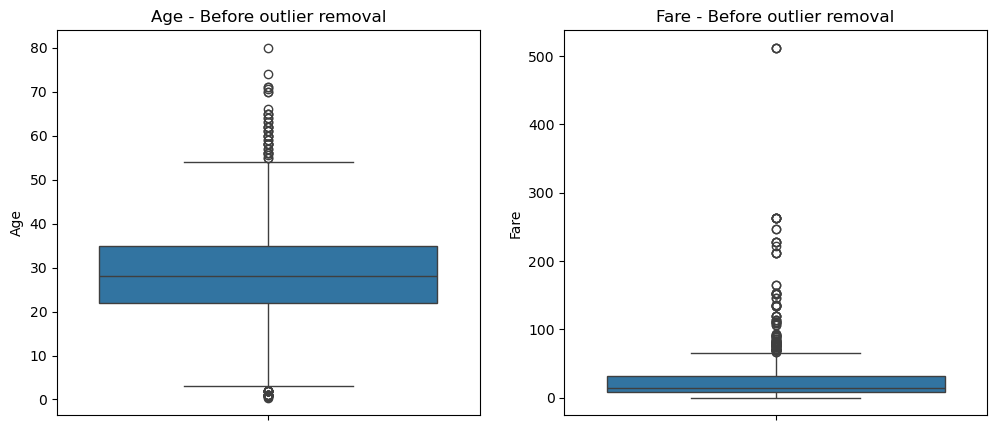

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(df['Age'])
plt.title('Age - Before outlier removal')

plt.subplot(1,2,2)
sns.boxplot(df['Fare'])
plt.title('Fare - Before outlier removal')

plt.show()


In [13]:
def remove_outliers(df, column): 
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)        
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Fare')

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (638, 8)


In [14]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

df = pd.get_dummies(df, columns= ['Embarked'], drop_first=True)
print('Columns after encoding:', df.columns.tolist())
print(df.head())


Columns after encoding: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0         0       3    1  22.0      1      0   7.2500       False        True
2         1       3    0  26.0      0      0   7.9250       False        True
4         0       3    1  35.0      0      0   8.0500       False        True
5         0       3    1  28.0      0      0   8.4583        True       False
8         1       3    0  27.0      0      2  11.1333       False        True


In [16]:
# Normalize Age and Fare to same scale
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

print("Data after normalization:")
print(df[['Age', 'Fare']].describe())

Data after normalization:
                Age          Fare
count  6.380000e+02  6.380000e+02
mean  -1.392129e-17 -2.784258e-18
std    1.000785e+00  1.000785e+00
min   -2.603912e+00 -1.523776e+00
25%   -6.850025e-01 -6.974595e-01
50%    3.458849e-02 -5.026110e-01
75%    3.943840e-01  6.283635e-01
max    2.553157e+00  3.431471e+00


In [17]:
# Save cleaned dataset
df.to_csv('titanic_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)
print("\nFinal columns:", df.columns.tolist())

Cleaned dataset saved successfully!
Final shape: (638, 9)

Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [18]:
print("="*50)
print("DATA CLEANING SUMMARY")
print("="*50)
print(f"Original dataset shape: (891, 12)")
print(f"Final dataset shape: {df.shape}")
print(f"\nSteps completed:")
print(f"1. Dropped useless columns: PassengerId, Name, Ticket, Cabin")
print(f"2. Filled missing Age with median")
print(f"3. Filled missing Embarked with mode")
print(f"4. Removed outliers using IQR method")
print(f"5. Encoded Sex using Label Encoding")
print(f"6. Encoded Embarked using One-Hot Encoding")
print(f"7. Normalized Age and Fare using StandardScaler")
print("="*50)

DATA CLEANING SUMMARY
Original dataset shape: (891, 12)
Final dataset shape: (638, 9)

Steps completed:
1. Dropped useless columns: PassengerId, Name, Ticket, Cabin
2. Filled missing Age with median
3. Filled missing Embarked with mode
4. Removed outliers using IQR method
5. Encoded Sex using Label Encoding
6. Encoded Embarked using One-Hot Encoding
7. Normalized Age and Fare using StandardScaler
